In [3]:
import pandas as pd

df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Missing Value Analysis:
No missing values were found in the dataset. Therefore, no imputation or row removal was required.

In [5]:
df.duplicated().sum()

0

In [8]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [9]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)

Q1 = 17.28
Q3 = 209.94
IQR = 192.66


In [10]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)


Lower Bound = -271.71000000000004
Upper Bound = 498.93


In [11]:
outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]

print("Number of Outliers:", len(outliers))

Number of Outliers: 1167


In [12]:
df = df[(df['Sales'] >= lower_bound) & (df['Sales'] <= upper_bound)]

print("New Shape:", df.shape)

New Shape: (8827, 21)


Outlier Handling:
The IQR method was applied to the Sales column. A total of 1167 outlier records were identified and removed. The dataset size was reduced from 9994 rows to 8827 rows.

In [13]:
df.to_csv("../data/cleaned_superstore.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [14]:
df.describe()


,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,8827.000000,8827,8827,8827.000000,8827.000000,8827.000000,8827.000000,8827.000000
mean,5016.375892,2016-05-02 15:45:12.541067264,2016-05-06 14:57:05.036818688,55373.635663,92.864853,3.608587,0.157606,11.198644
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-1181.282400
25%,2508.500000,2015-05-28 00:00:00,2015-05-31 00:00:00,23320.000000,15.008000,2.000000,0.000000,1.702400
50%,5028.000000,2016-07-01 00:00:00,2016-07-03 00:00:00,59801.000000,40.880000,3.000000,0.200000,7.437600
75%,7517.500000,2017-05-15 00:00:00,2017-05-19 00:00:00,90008.000000,124.225000,5.000000,0.200000,21.335400
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,498.260000,14.000000,0.800000,240.859500
std,2888.406540,NaN,NaN,31974.536840,114.045078,2.129308,0.211531,49.066101


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8827 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         8827 non-null   int64         
 1   Order ID       8827 non-null   object        
 2   Order Date     8827 non-null   datetime64[ns]
 3   Ship Date      8827 non-null   datetime64[ns]
 4   Ship Mode      8827 non-null   object        
 5   Customer ID    8827 non-null   object        
 6   Customer Name  8827 non-null   object        
 7   Segment        8827 non-null   object        
 8   Country        8827 non-null   object        
 9   City           8827 non-null   object        
 10  State          8827 non-null   object        
 11  Postal Code    8827 non-null   int64         
 12  Region         8827 non-null   object        
 13  Product ID     8827 non-null   object        
 14  Category       8827 non-null   object        
 15  Sub-Category   8827 non-nu

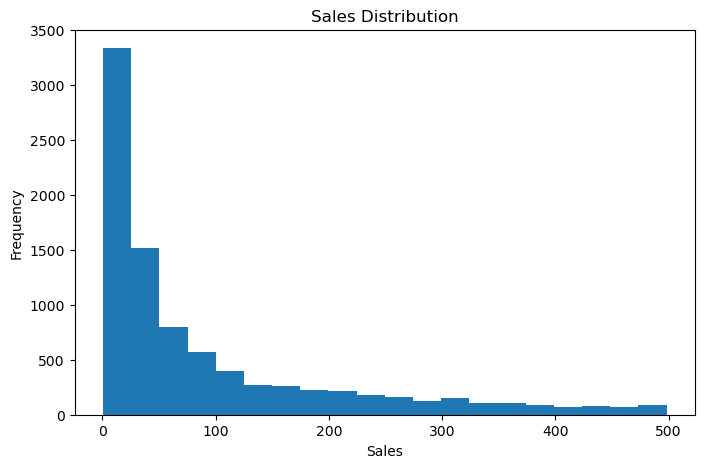

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins=20)

plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

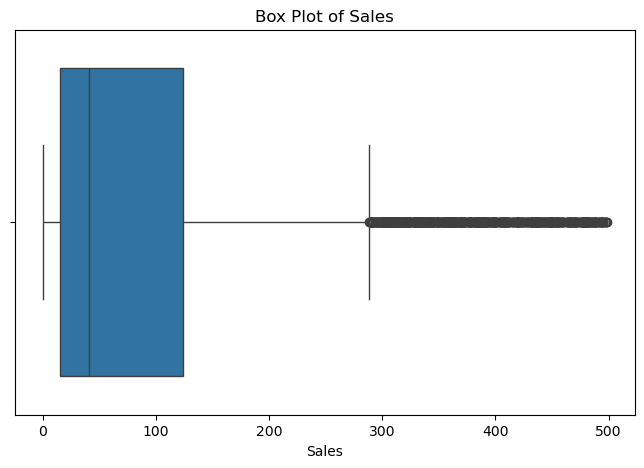

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Sales'])

plt.title('Box Plot of Sales')
plt.show()

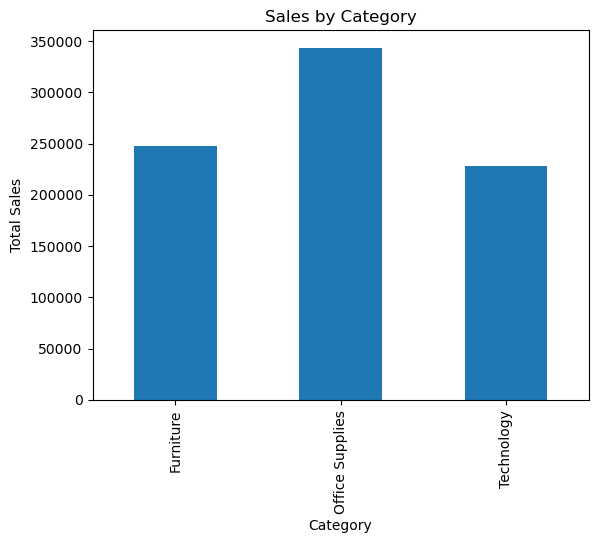

In [19]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.show()

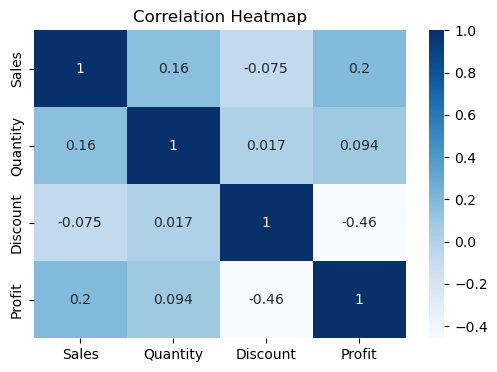

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    df[['Sales','Quantity','Discount','Profit']].corr(),
    annot=True,
    cmap='Blues'
)

plt.title('Correlation Heatmap')
plt.show()

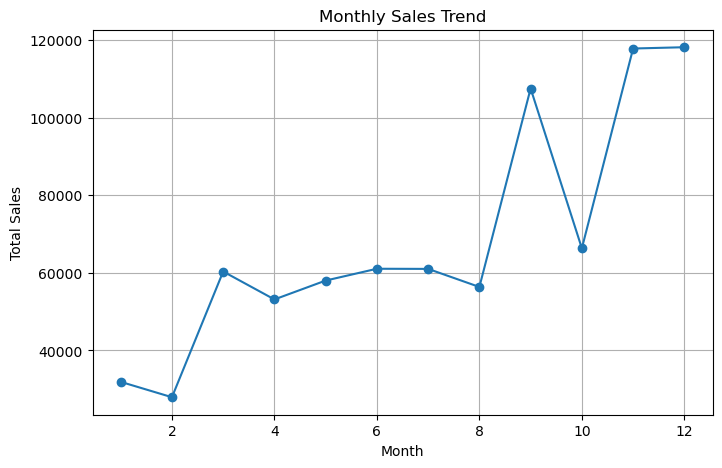

In [21]:
monthly_sales = df.groupby(df['Order Date'].dt.month)['Sales'].sum()

plt.figure(figsize=(8,5))

monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.grid(True)
plt.show()

Key Insights from Analysis

1. No missing values or duplicate records were found in the dataset, indicating good data quality.

2. The sales distribution is positively skewed, meaning most orders have lower sales values while only a few orders generate very high sales.

3. Office Supplies generated the highest total sales among all product categories.

4. Discount and Profit show a moderate negative correlation (-0.46), indicating that higher discounts generally reduce profitability.

5. Sales increased significantly toward the end of the year, with November and December recording the highest sales volumes.